# Hyperspectral Benchmarking

This notebook contains the benchmarking of TreeLUT on hyperspectral datasets.

Table of Contents:
1. [Setup and Data Loading](#setup)
2. [Data Preprocessing](#preprocessing)
3. [Model Training](#training)
4. [Model Evaluation](#evaluation)
5. [Verilog Code Generation (TreeLUT)](#verilog)
6. [FPGA Synthesis and Resource Utilization](#synthesis)

## Setup and Data Loading <a name="setup"></a>

Import necessary libraries and load the hyperspectral dataset.

In [19]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

import timeit
import scipy.io
import requests
import time
import joblib

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                            f1_score, precision_score, recall_score, cohen_kappa_score)


from treelut import TreeLUTClassifier

### Benchmark Parameters

In [20]:
benchmark = {
    'dataset' : 'paviaU',
    'model': 'lgbm'
}

lgbm_params = {
    'objective': 'multiclass',
    'random_state': 42,
    'n_estimators': 13,
    'max_depth': 6,
    'eta': 0.1,
    'verbose': -1
}

xgb_params = {
    'objective': 'multi:softmax',
    'random_state': 42,
    'n_estimators': 3,
    'max_depth': 6,
    'verbosity': 0,
    'n_jobs': -1,
    'device': 'cuda'
}

treelut_params = {
    'w_feature': 8, 
    'w_tree': 8,
    'bits_features': 16,
    'pipeline': [0, 0, 0], 
    'dir_path': f'./results/{benchmark['dataset']}/',
    'style': 'mux',
    'argmax': True,
    'quantized': True
}

### Load Data

IMAGES is a dictionary containing information about available hyperspectral images. Each entry includes the image name, file path, and ground truth path.


In [21]:
# Images information
IMAGES = {
    "indian_pines": {
        "file": "Indian_pines_corrected.mat",
        "file_gt": "Indian_pines_gt.mat",
        "key": "indian_pines_corrected",
        "key_gt": "indian_pines_gt",
        "url": "http://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat",
        "url_gt": "http://www.ehu.eus/ccwintco/uploads/c/c4/Indian_pines_gt.mat",
        "p": 0.15
    },
    "KSC": {
        "file": "KSC.mat",
        "file_gt": "KSC_gt.mat",
        "key": "KSC",
        "key_gt": "KSC_gt",
        "url": "http://www.ehu.es/ccwintco/uploads/2/26/KSC.mat",
        "url_gt": "http://www.ehu.es/ccwintco/uploads/a/a6/KSC_gt.mat",
        "p": 0.15
    },
    "paviaU": {
        "file": "PaviaU.mat",
        "file_gt": "PaviaU_gt.mat",
        "key": "paviaU",
        "key_gt": "paviaU_gt",
        "url": "http://www.ehu.eus/ccwintco/uploads/e/ee/PaviaU.mat",
        "url_gt": "http://www.ehu.eus/ccwintco/uploads/5/50/PaviaU_gt.mat",
        "p": 0.15
    },
    "salinas": {
        "file": "Salinas.mat",
        "file_gt": "Salinas_gt.mat",
        "key": "salinas",
        "key_gt": "salinas_gt",
        "url": "http://www.ehu.eus/ccwintco/uploads/f/f1/Salinas.mat",
        "url_gt": "http://www.ehu.eus/ccwintco/uploads/f/fa/Salinas_gt.mat",
        "p": 0.15
    }
}


In [22]:
def load_image(image_info, data_path="."):
    """Loads the image and the ground truth from a `mat` file.
    
    If the file is not present in the `data_path` directory, downloads
    the file from the `image_info` url.
    
    Parameters
    ----------
    image_info: dict
        Dict structure with information of the image.
    data_path: str, optional (default ".")
        Absolute route of the directory of the image files.
    
    Returns
    -------
    X: NumPy array
        The loaded image data.
    y: NumPy array
        The loaded ground truth data.
    
    """
    # Image name
    image_name = image_info['key']

    # Verify data path
    if not os.path.exists(data_path):
        os.makedirs(data_path)
    
    # Filenames
    input_file = os.path.join(data_path, image_info['file'])
    label_file = os.path.join(data_path, image_info['file_gt'])
    
    # LOAD IMAGE
    try:
        X = scipy.io.loadmat(input_file)[image_name]
    except:
        os.system("wget {} -O {}".format(image_info['url'], input_file))
        X = scipy.io.loadmat(input_file)[image_name]
    
    # LOAD GROUND TRUTH
    try:
        y = scipy.io.loadmat(label_file)[image_info['key_gt']]
    except:
        os.system("wget {} -O {}".format(image_info['url_gt'], label_file))
        y = scipy.io.loadmat(label_file)[image_info['key_gt']]
    

    return X, y

def plot_img(image, title="Image", cmap='jet'):
    """Plots a hyperspectral image.
    
    Parameters
    ----------
    image: NumPy array
        The hyperspectral image to be plotted.
    title: str, optional (default "Image")
        The title of the plot.
    cmap: str, optional (default 'jet')
        The colormap to be used in the plot.
    """

    plt.figure(figsize=(8, 8))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

def pixel_classification_preprocessing(X, y):
    """Preprocesses hyperspectral images for pixel classification.
    
    Reshapes the image and the ground truth data, keeps only the labeled
    pixels and renames the classes to ordered integers from 0.
    
    Parameters
    ----------
    X: NumPy array
        The image data.
    y: NumPy array
        The ground truth data.
    
    Returns
    -------
    X: NumPy array
        The prepreocessed pixels.
    y: NumPy array
        The prepreocessed labels.
    
    """
    # Reshape them to ignore spatiality
    X = X.reshape(-1, X.shape[2])
    y = y.reshape(-1)
    
    # Keep only labeled pixels
    X = X[y > 0, :]
    y = y[y > 0]
    
    # Rename clases to ordered integers from 0
    for new_class_num, old_class_num in enumerate(np.unique(y)):
        y[y == old_class_num] = new_class_num
    
    return X, y

    

In [23]:
imag_name, imag_info = benchmark['dataset'],IMAGES.get(benchmark['dataset'])
data, labels = load_image(imag_info, data_path="./data")
print(f"Image shape: {data.shape}")
print(f"Ground truth shape: {labels.shape}\n")

X, y = pixel_classification_preprocessing(data,labels)
print(f"\nLabeled samples shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Number of classes: {len(np.unique_counts(y)[0])}")

lgbm_params['num_class'], xgb_params['num_class'] = len(np.unique_counts(y)[0]),len(np.unique_counts(y)[0])

Image shape: (610, 340, 103)
Ground truth shape: (610, 340)


Labeled samples shape: (42776, 103)
Labels shape: (42776,)
Number of classes: 9


Feature Distributions

In [24]:
# 1. Create the DataFrame
X_df = pd.DataFrame(X, columns=[f'Band_{i}' for i in range(X.shape[1])])
X_df.describe()

,Band_0,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,...,Band_93,Band_94,Band_95,Band_96,Band_97,Band_98,Band_99,Band_100,Band_101,Band_102
count,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,...,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000,42776.000000
mean,945.767206,873.462549,828.101903,846.139751,873.275645,880.896110,883.096643,877.592248,877.524313,886.931387,...,2339.118852,2342.862844,2331.715308,2323.073523,2323.171849,2317.270549,2310.708201,2304.378904,2318.662428,2335.266131
std,492.146995,522.664726,555.372675,597.175830,633.413028,660.102265,685.573042,705.881023,726.748267,751.663472,...,864.667595,866.046858,861.765157,851.672251,839.105526,832.406780,832.914448,832.898594,839.194643,849.072028
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,39.000000,63.000000,43.000000,12.000000,...,141.000000,126.000000,152.000000,164.000000,195.000000,177.000000,140.000000,135.000000,138.000000,148.000000
25%,655.000000,559.000000,486.000000,481.000000,494.000000,493.000000,481.000000,464.000000,455.000000,456.000000,...,1816.000000,1818.000000,1804.000000,1796.000000,1805.000000,1806.000000,1795.000000,1783.000000,1795.000000,1809.000000
50%,864.000000,770.000000,705.000000,712.000000,721.000000,707.000000,699.000000,691.500000,687.000000,687.000000,...,2304.000000,2309.000000,2296.000000,2285.000000,2295.000000,2296.000000,2293.000000,2295.000000,2316.000000,2331.000000
75%,1124.000000,1073.000000,1059.000000,1090.000000,1115.000000,1121.000000,1128.000000,1123.000000,1126.000000,1144.000000,...,2712.000000,2720.000000,2716.000000,2712.000000,2705.000000,2691.000000,2684.000000,2677.000000,2694.000000,2715.000000
max,4595.000000,4994.000000,5436.000000,5999.000000,6526.000000,6824.000000,7158.000000,7342.000000,7470.000000,7773.000000,...,6658.000000,6606.000000,6440.000000,6332.000000,6294.000000,6317.000000,6320.000000,6264.000000,6285.000000,6329.000000


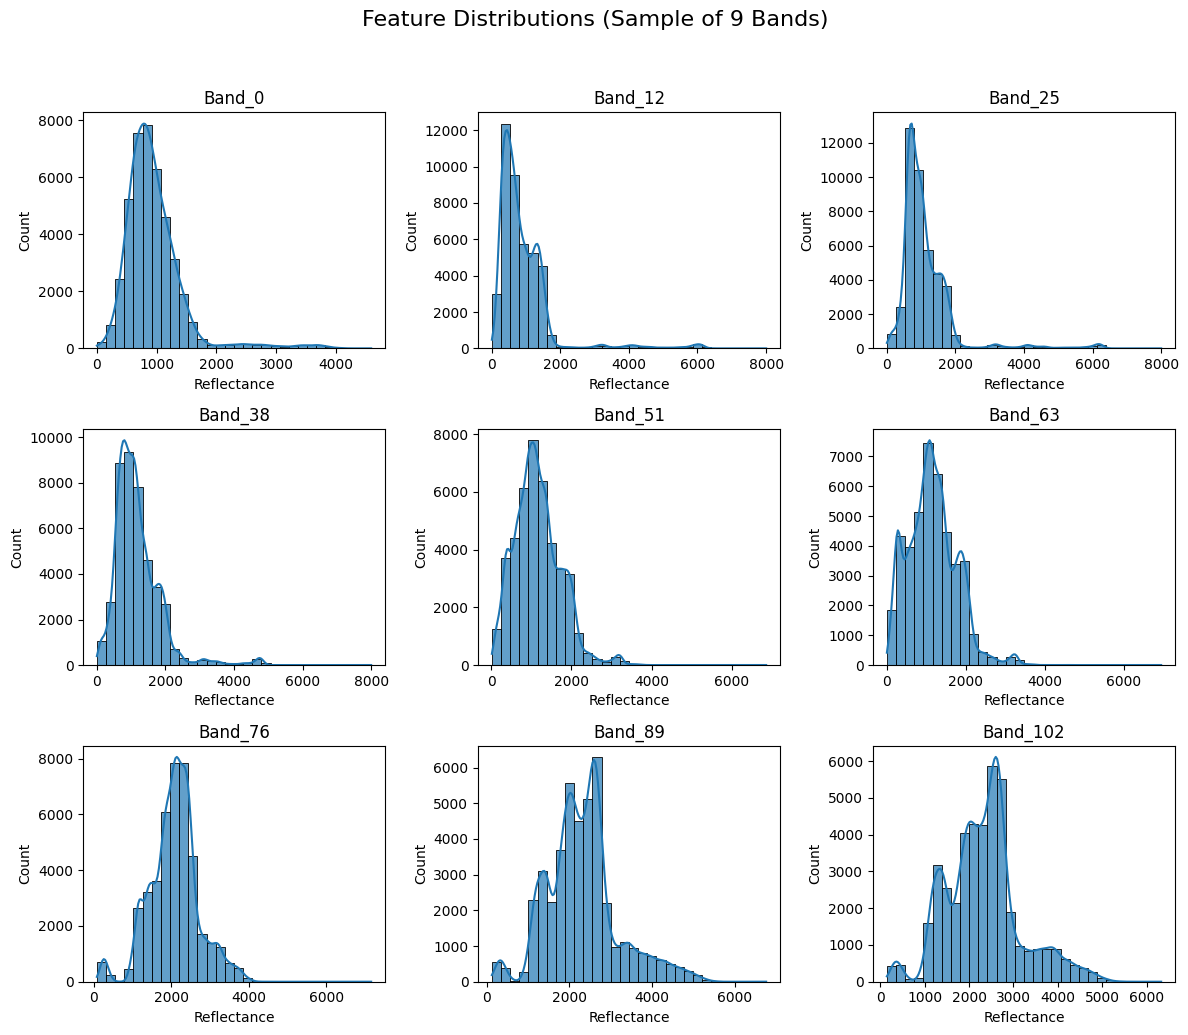

In [25]:
# 2. Select a sample of bands to plot (e.g., 9 bands spaced evenly)
sample_band_indices = np.linspace(0, X.shape[1] - 1, 9, dtype=int)
sample_band_names = [f'Band_{i}' for i in sample_band_indices]

# 3. Create the figure and the plots
plt.figure(figsize=(12, 10))

for i, col in enumerate(sample_band_names):
    plt.subplot(3, 3, i + 1)
    # Use histplot to show the distribution
    sns.histplot(X_df[col], kde=True, bins=30, alpha=0.7)
    plt.title(col)
    plt.xlabel('Reflectance')
    plt.ylabel('Count')

# 4. Now add your super-title and layout adjustments
plt.suptitle('Feature Distributions (Sample of 9 Bands)', fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

Class Distribution

In [26]:
# Class distribution
unique_classes, class_counts = np.unique(y, return_counts=True)
class_dist = pd.DataFrame({
    'Class ID': unique_classes,
    'Count': class_counts,
    'Percentage': (class_counts / len(y) * 100).round(2)
}).sort_values('Count', ascending=False)

print("\nClass Distribution:")
class_dist



Class Distribution:


,Class ID,Count,Percentage
1,1,18649,43.60
0,0,6631,15.50
5,5,5029,11.76
7,7,3682,8.61
3,3,3064,7.16
2,2,2099,4.91
4,4,1345,3.14
6,6,1330,3.11
8,8,947,2.21


Visualizations

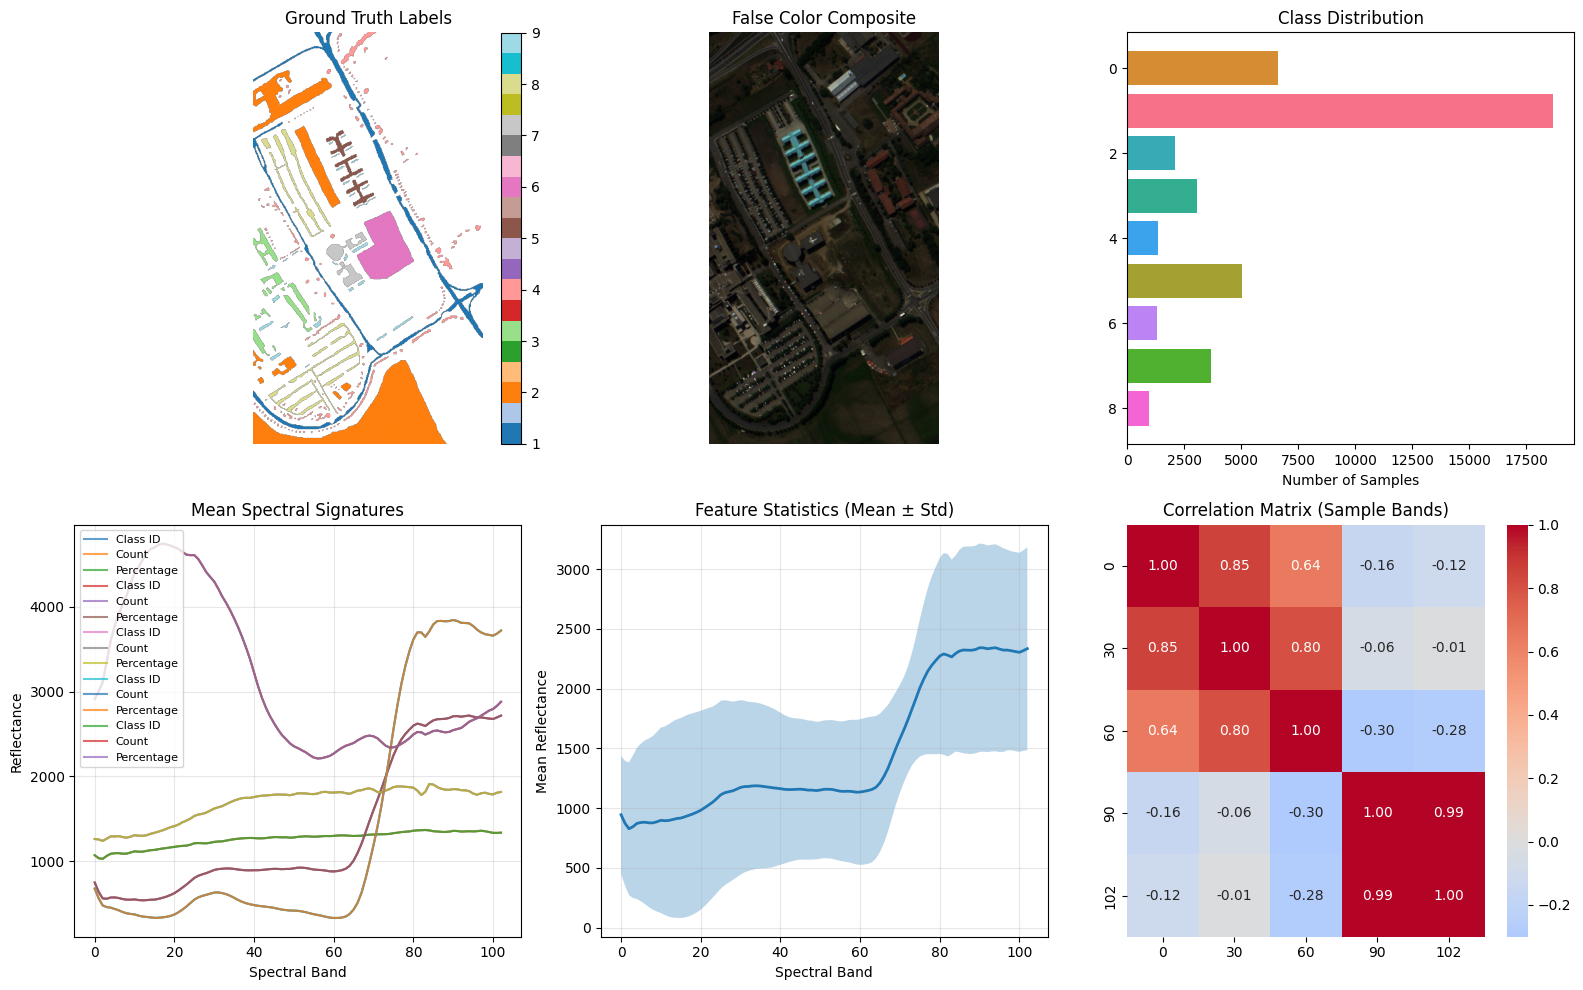

In [27]:
fig = plt.figure(figsize=(16, 10))

# 1. Ground truth visualization
ax1 = plt.subplot(2, 3, 1)

# Make a copy and change its type to float
labels_vis = labels.copy().astype(float) 

# Now you can safely assign np.nan
labels_vis[labels_vis == 0] = np.nan 

im1 = ax1.imshow(labels_vis, cmap='tab20')
ax1.set_title('Ground Truth Labels')
ax1.axis('off')
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# 2. False color composite (using 3 spectral bands)
ax2 = plt.subplot(2, 3, 2)
rgb_bands = data[:, :, [50, 30, 10]]  # Select bands for RGB
rgb_bands = (rgb_bands - rgb_bands.min()) / (rgb_bands.max() - rgb_bands.min())
ax2.imshow(rgb_bands)
ax2.set_title('False Color Composite')
ax2.axis('off')

# 3. Class distribution bar plot
ax3 = plt.subplot(2, 3, 3)
bars = ax3.barh(class_dist['Class ID'], class_dist['Count'], color=sns.color_palette('husl', len(class_dist)))
ax3.set_xlabel('Number of Samples')
ax3.set_title('Class Distribution')
ax3.invert_yaxis()

# 4. Spectral signature examples
ax4 = plt.subplot(2, 3, 4)
for class_id in unique_classes[:5]:
    class_samples = X[y == class_id]
    if len(class_samples) > 0:
        mean_spectrum = class_samples.mean(axis=0)
        ax4.plot(mean_spectrum, label=class_dist[class_dist['Class ID'] == class_id], alpha=0.7)
ax4.set_xlabel('Spectral Band')
ax4.set_ylabel('Reflectance')
ax4.set_title('Mean Spectral Signatures')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# 5. Feature statistics
ax5 = plt.subplot(2, 3, 5)
band_means = X.mean(axis=0)
band_stds = X.std(axis=0)
ax5.fill_between(range(X.shape[1]), band_means - band_stds, band_means + band_stds, alpha=0.3)
ax5.plot(band_means, linewidth=2)
ax5.set_xlabel('Spectral Band')
ax5.set_ylabel('Mean Reflectance')
ax5.set_title('Feature Statistics (Mean ± Std)')
ax5.grid(True, alpha=0.3)

# 6. Correlation heatmap (sample)
ax6 = plt.subplot(2, 3, 6)
sample_bands = [0, 30, 60, 90, 102]
corr_matrix = np.corrcoef(X[:, sample_bands].T)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=sample_bands, yticklabels=sample_bands, ax=ax6)
ax6.set_title('Correlation Matrix (Sample Bands)')



plt.tight_layout()
plt.show()

## Data Preprocessing <a name="preprocessing"></a>

Reshapes the image and the ground truth data, keeps only the labeled pixels and renames the classes to ordered integers from 0.

In [28]:
def pixel_classification_preprocessing(X, y):
    """Preprocesses hyperspectral images for pixel classification.
    
    Reshapes the image and the ground truth data, keeps only the labeled
    pixels and renames the classes to ordered integers from 0.
    
    Parameters
    ----------
    X: NumPy array
        The image data.
    y: NumPy array
        The ground truth data.
    
    Returns
    -------
    X: NumPy array
        The prepreocessed pixels.
    y: NumPy array
        The prepreocessed labels.
    
    """
    # Reshape them to ignore spatiality
    X = X.reshape(-1, X.shape[2])
    y = y.reshape(-1)
    
    # Keep only labeled pixels
    X = X[y > 0, :]
    y = y[y > 0]
    
    # Rename clases to ordered integers from 0
    for new_class_num, old_class_num in enumerate(np.unique(y)):
        y[y == old_class_num] = new_class_num
    
    return X, y

Separates the data into training and testing sets, change the scale of the data, and trains the XGBoost baseline model.

In [29]:
X, y = pixel_classification_preprocessing(data, labels)
X = pd.DataFrame(X)
y = pd.Series(y)
print(f"Preprocessed data shape: {X.shape}")
print(f"Preprocessed labels shape: {y.shape}")

Preprocessed data shape: (42776, 103)
Preprocessed labels shape: (42776,)


In [30]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]:,} samples")
print(f"Test set size: {X_test.shape[0]:,} samples")
print(f"Number of features: {X_train.shape[1]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler")

Training set size: 29,943 samples
Test set size: 12,833 samples
Number of features: 103
✅ Features scaled using StandardScaler


In [31]:
# Get max and min of each column of X_test
max_values = X_test.max()
min_values = X_test.min()

# To np arrays
max_values = max_values.to_numpy()
min_values = min_values.to_numpy()


In [32]:
scaler = MinMaxScaler()
w_feature = treelut_params['w_feature']
X_train_min_max = np.round(scaler.fit_transform(X_train)*(2**w_feature-1))
X_test_min_max = np.clip(np.round(scaler.transform(X_test)*(2**w_feature-1)), 0, 2**w_feature-1)

## Model Training <a name="training"></a>

Apply model parameters and train the model using the training dataset using XGBoost.

### XGBoost model

In [33]:
print("1️⃣ Training XGBoost Baseline...")
start_time = time.time()
xgb_baseline = XGBClassifier(**xgb_params)
xgb_baseline.fit(X_train, y_train)
xgb_train_time = time.time() - start_time
print(f"✅ XGBoost trained in {xgb_train_time:.2f} seconds")

1️⃣ Training XGBoost Baseline...
✅ XGBoost trained in 0.44 seconds


In [34]:
print("2️⃣ Training XGBoost Min-Max")
start_time = time.time()
xgb_min_max = XGBClassifier(**xgb_params)
xgb_min_max.fit(X_train_min_max, y_train)
xgb_train_time = time.time() - start_time
print(f"✅ XGBoost trained in {xgb_train_time:.2f} seconds")


2️⃣ Training XGBoost Min-Max
✅ XGBoost trained in 0.20 seconds


### LightGMB model

In [35]:
print("1️⃣ Training LightGBM Baseline...")
start_time = time.time()
lgbm_baseline = LGBMClassifier(**lgbm_params)
lgbm_baseline.fit(X_train, y_train)
lgbm_train_time = time.time() - start_time
print(f"✅ LightGBM trained in {lgbm_train_time:.2f} seconds")

1️⃣ Training LightGBM Baseline...
✅ LightGBM trained in 0.39 seconds


In [36]:
print("2️⃣ Training LightGBM Min-Max")
start_time = time.time()
lgbm_min_max = LGBMClassifier(**lgbm_params)
lgbm_min_max.fit(X_train_min_max, y_train)
lgbm_train_time = time.time() - start_time
print(f"✅ LightGBM trained in {lgbm_train_time:.2f} seconds")


2️⃣ Training LightGBM Min-Max
✅ LightGBM trained in 0.32 seconds


Evaluate the trained model on the test dataset and print classification report.

In [37]:
baseline_y_hat = xgb_baseline.predict(X_test)
print("📋 XGBoost Classification Baseline Accuracy:")
print(f'Accuracy: {accuracy_score(y_test, baseline_y_hat):.4f}')

min_max_y_hat = xgb_min_max.predict(X_test_min_max)
print("📋 XGBoost Classification Min-Max Accuracy:")
print(f'Accuracy: {accuracy_score(y_test, min_max_y_hat):.4f}')


📋 XGBoost Classification Baseline Accuracy:
Accuracy: 0.8597
📋 XGBoost Classification Min-Max Accuracy:
Accuracy: 0.8610


In [38]:
lgbm_baseline_y_hat = lgbm_baseline.predict(X_test)
print("📋 XGBoost Classification Baseline Accuracy:")
print(f'Accuracy: {accuracy_score(y_test, lgbm_baseline_y_hat):.4f}')

lgbm_min_max_y_hat = lgbm_min_max.predict(X_test_min_max)
print("📋 XGBoost Classification Min-Max Accuracy:")
print(f'Accuracy: {accuracy_score(y_test, lgbm_min_max_y_hat):.4f}')


📋 XGBoost Classification Baseline Accuracy:
Accuracy: 0.8870
📋 XGBoost Classification Min-Max Accuracy:
Accuracy: 0.8861


/home/olavo/Área de trabalho/ufv/projects/TreeLUT/env/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Model Evaluation <a name="evaluation"></a>

In [39]:
def node_count_scorer(estimator):
    """
    Custom scorer that returns the total number of nodes in a
    fitted XGBoost or LightGBM model.
    
    Returns the *negative* count, as scikit-learn scorers are maximized.
    """
    node_count = 0
    if isinstance(estimator, XGBClassifier):
        try:
            # Get the dataframe of all trees
            df = estimator.get_booster().trees_to_dataframe()
            node_count = df.shape[0] # Number of rows = total nodes
        except Exception as e:
            print(f"Warning: Could not get XGB node count: {e}")
            node_count = 0
            
    elif isinstance(estimator, LGBMClassifier):
        try:
            # Get the dataframe of all trees
            df = estimator.booster_.trees_to_dataframe()
            node_count = df.shape[0] # Number of rows = total nodes
        except Exception as e:
            print(f"Warning: Could not get LGBM node count: {e}")
            node_count = 0
    else:
        # Failsafe for other models
        pass

    # We want to MINIMIZE nodes, so we MAXIMIZE the negative count
    # e.g., -100 (100 nodes) is > -1000 (1000 nodes)
    return node_count

def evaluate_model(y_true, y_pred, model_name, model):
    """Calculate and display model metrics"""
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted')
    kappa = cohen_kappa_score(y_true, y_pred)
    n_nodes = node_count_scorer(model)
    
    print(f"\n{model_name} Performance:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  Kappa:     {kappa:.4f}")
    print(f"  N Nodes:   {n_nodes}")
    
    return {
        'Model': model_name,
        'Accuracy': acc,
        'F1 Score': f1,
        'Precision': precision,
        'Recall': recall,
        'Kappa': kappa,
        "Num Nodes": n_nodes
    }

In [40]:
xgb_metrics_baseline = evaluate_model(y_test, baseline_y_hat, "XGBoost Baseline", xgb_baseline)
xgb_metrics_min_max = evaluate_model(y_test, min_max_y_hat, "XGBoost Min-Max", xgb_min_max)
df1 = pd.DataFrame([xgb_metrics_baseline, xgb_metrics_min_max])




XGBoost Baseline Performance:
  Accuracy:  0.8597
  F1 Score:  0.8490
  Precision: 0.8651
  Recall:    0.8597
  Kappa:     0.8081
  N Nodes:   1695

XGBoost Min-Max Performance:
  Accuracy:  0.8610
  F1 Score:  0.8502
  Precision: 0.8671
  Recall:    0.8610
  Kappa:     0.8097
  N Nodes:   1705


In [41]:
lgbm_metrics_baseline = evaluate_model(y_test, lgbm_baseline_y_hat, "LightGBM Baseline", lgbm_baseline)
lgbm_metrics_min_max = evaluate_model(y_test, lgbm_min_max_y_hat, "LightGBM Min-Max", lgbm_min_max)
df2 = pd.DataFrame([lgbm_metrics_baseline, lgbm_metrics_min_max])




LightGBM Baseline Performance:
  Accuracy:  0.8870
  F1 Score:  0.8804
  Precision: 0.8920
  Recall:    0.8870
  Kappa:     0.8462
  N Nodes:   6889

LightGBM Min-Max Performance:
  Accuracy:  0.8861
  F1 Score:  0.8795
  Precision: 0.8908
  Recall:    0.8861
  Kappa:     0.8450
  N Nodes:   6741


In [42]:
print("\nOverall Results:")
results_df = result = pd.concat([df1, df2])
results_df


Overall Results:


,Model,Accuracy,F1 Score,Precision,Recall,Kappa,Num Nodes
0,XGBoost Baseline,0.859659,0.849031,0.865110,0.859659,0.808082,1695
1,XGBoost Min-Max,0.860983,0.850152,0.867071,0.860983,0.809742,1705
0,LightGBM Baseline,0.887010,0.880369,0.892020,0.887010,0.846213,6889
1,LightGBM Min-Max,0.886075,0.879529,0.890805,0.886075,0.845013,6741


XGBoost confusion matrix


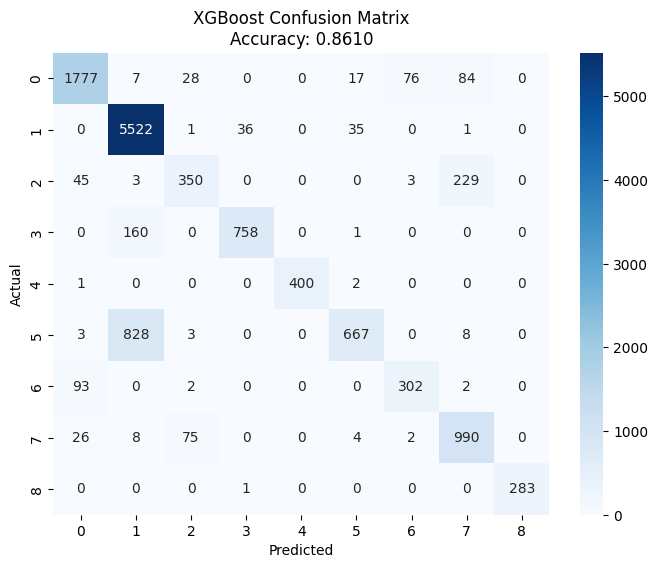

In [43]:
# XGBoost confusion matrix

fig, ax = plt.subplots(figsize=(8, 6))
cm_xgb = confusion_matrix(y_test, min_max_y_hat)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'XGBoost Confusion Matrix\nAccuracy: {xgb_metrics_min_max["Accuracy"]:.4f}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.show()

In [44]:
print("\n📋 XGBoost Classification Report:")
print(classification_report(y_test, min_max_y_hat))


📋 XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1989
           1       0.85      0.99      0.91      5595
           2       0.76      0.56      0.64       630
           3       0.95      0.82      0.88       919
           4       1.00      0.99      1.00       403
           5       0.92      0.44      0.60      1509
           6       0.79      0.76      0.77       399
           7       0.75      0.90      0.82      1105
           8       1.00      1.00      1.00       284

    accuracy                           0.86     12833
   macro avg       0.88      0.82      0.84     12833
weighted avg       0.87      0.86      0.85     12833



## Verilog Code Generation (TreeLUT) <a name="verilog"></a>

In [45]:
treelut_X_test = X_test if treelut_params['quantized'] else X_test_min_max
model = lgbm_min_max if benchmark['model'] == 'lgbm' else xgb_min_max


treelut_clf = TreeLUTClassifier(xgb_model=model, **treelut_params, min=min_values, max=max_values)
treelut_clf.convert()
y_pred_treelut = treelut_clf.predict(X_test_min_max)
print(f"TreeLUT Model Accuracy: {accuracy_score(y_pred_treelut, y_test):.3f}")

treelut_clf.verilog()
treelut_clf.testbench(treelut_X_test, y_test)

TreeLUT Model Accuracy: 0.886


## FPGA Synthesis and Resource Utilization <a name="synthesis"></a>

In [46]:
def load_scripts_from_txt():
    """
    Reads the Yosys and ABC script content from their respective .txt files.

    Returns:
        dict: A dictionary with 'yosys' and 'abc' keys holding the script content.
              Returns None for a script if its file is not found.
    """
    scripts = {}
    
    try:
        with open("misc/yosys_script.ys", "r", encoding="utf-8") as f:
            scripts['yosys'] = f.read()
    except FileNotFoundError:
        print("Warning: 'yosys_script.txt' not found.")
        scripts['yosys'] = None

    return scripts

In [47]:
loaded_scripts = load_scripts_from_txt()

if loaded_scripts['yosys']:
    print("--- YOSYS SCRIPT (from .txt) ---")
    # You still need to format the placeholder
    with open("yosys_script_temp.ys", "w", encoding="utf-8") as f:
        f.write(loaded_scripts['yosys'].format(dir_path=treelut_params['dir_path']))


--- YOSYS SCRIPT (from .txt) ---


In [48]:
!yosys -s yosys_script_temp.ys 2>/dev/null > report.txt